## Computer Vision - Tirana May 2026
# Final Evaluation Exercise: Complete the following exercises

Remember to send your solution to my email: christian.mata@upc.edu


## 1. Load and visualize the 'coins' image from the skimage built-in datasets. Report the size of the image and range of the pixel grayscale levels.

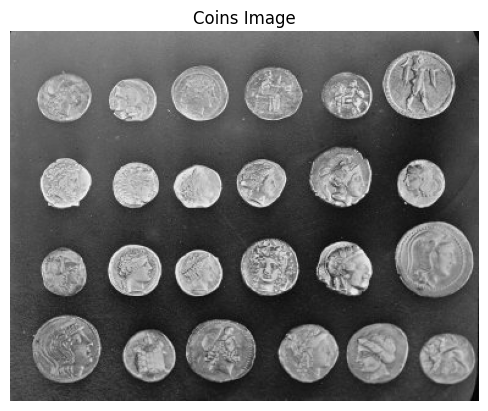

Image size: (303, 384)
Pixel value range: min = 1 , max = 252


In [ ]:
import matplotlib.pyplot as plt
from skimage import data

# Loading Image
coins = data.coins()

# Visualization
plt.imshow(coins, cmap='gray')
plt.title('Coins Image')
plt.axis('off')
plt.show()

# Image properties
print("Image size:", coins.shape)
print("Pixel value range: min =", coins.min(), ", max =", coins.max())

## 2. Represent the histogram of the image. Explain the peaks of the histogram in terms of regions of the image.

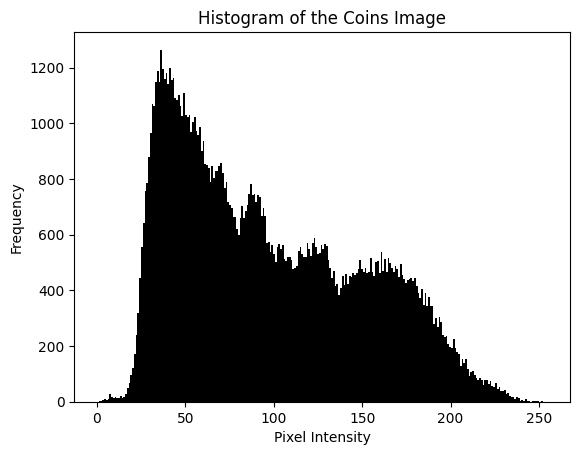

In [ ]:
coins = data.coins()

# Plot the histogram of pixel intensities
plt.hist(coins.ravel(), bins=256, range=(0, 255), color='black')
plt.title('Histogram of the Coins Image')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.show()

In the image analysis, low-intensity pixels correspond mainly to the background and shadowed regions. Mid-range intensities are associated with the surfaces of the coins, which exhibit varying gray levels due to texture and uneven illumination. High-intensity pixels correspond to specular highlights and reflections on the metallic surfaces of the coins. These distinct intensity distributions produce multiple peaks in the histogram, reflecting the different structural components of the image (background, coin bodies, and highlights), which is useful for image segmentation and analysis.

## 3. Applied noise to the image and use the correct function to erase the noise.

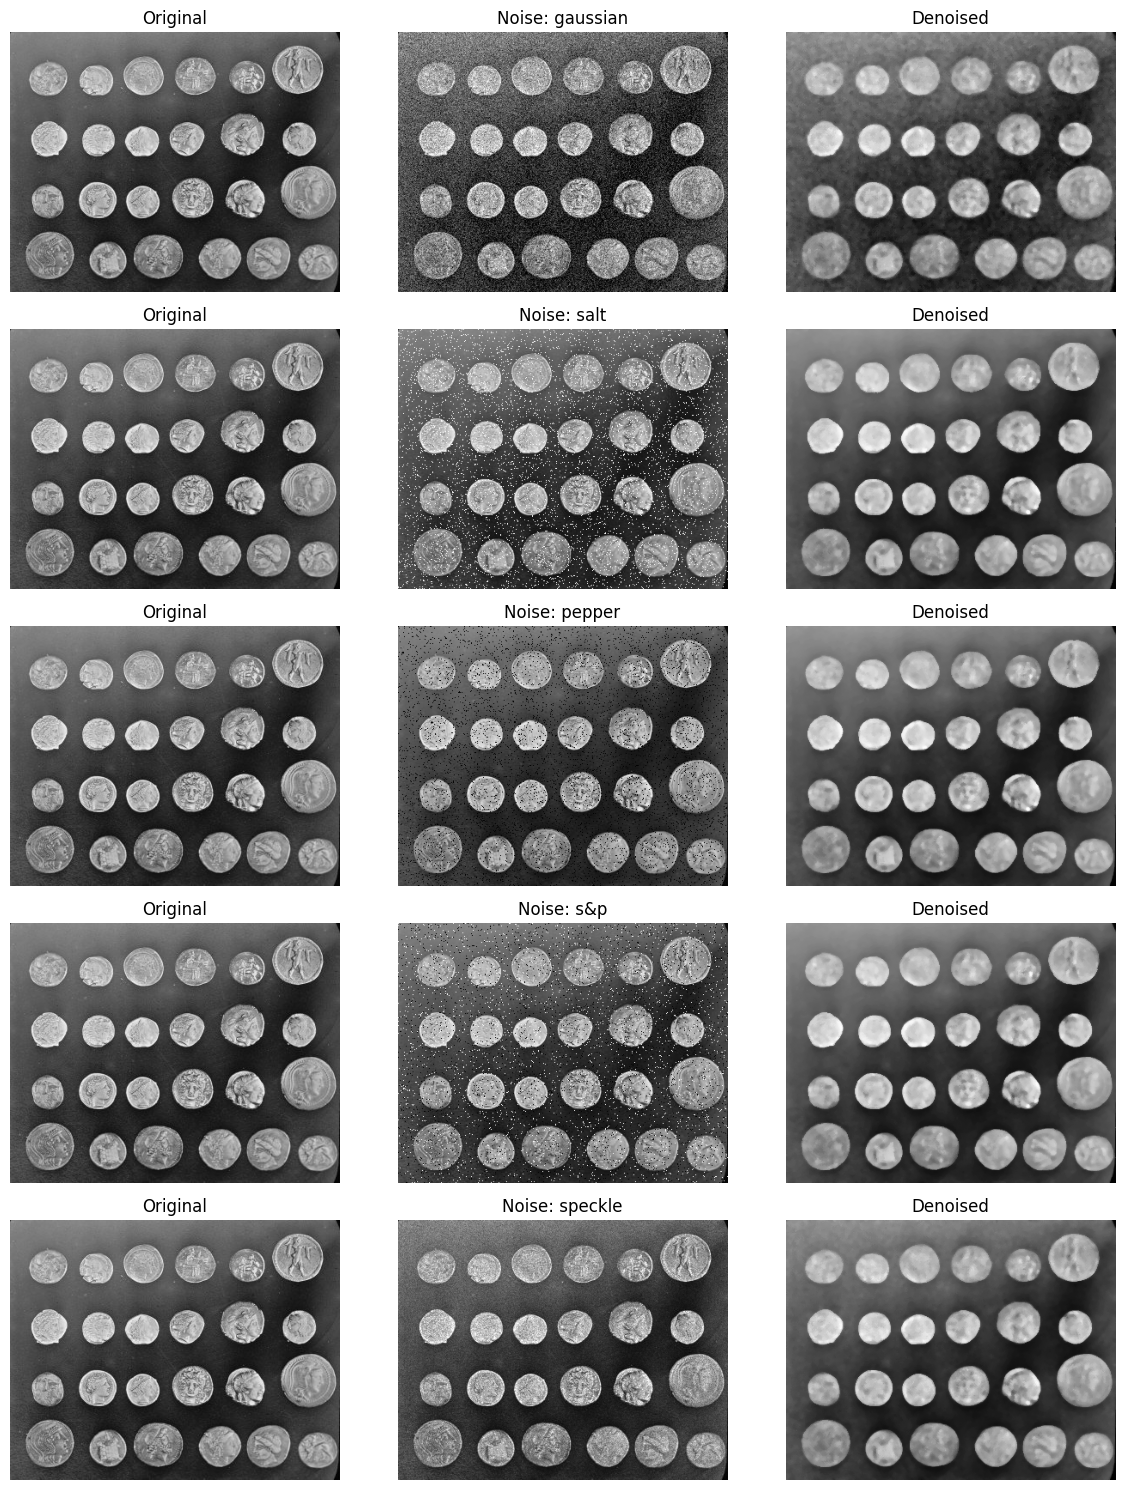

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import data
from skimage.util import random_noise
from skimage.filters import median
from skimage.morphology import disk

coins = data.coins()

# Different noise types
noise_types = ['gaussian', 'salt', 'pepper', 's&p', 'speckle']

fig, axes = plt.subplots(len(noise_types), 3, figsize=(12, 15))

for i, noise_type in enumerate(noise_types):

    # Adding noise
    noisy_image = random_noise(coins, mode=noise_type)

    # Converting to uint8 for filtering
    noisy_uint8 = (noisy_image * 255).astype(np.uint8)

    # Applying median filter to remove noise
    denoised_image = median(noisy_uint8, disk(3))

    # Original image
    axes[i, 0].imshow(coins, cmap='gray')
    axes[i, 0].set_title('Original')
    axes[i, 0].axis('off')

    # Noisy image
    axes[i, 1].imshow(noisy_image, cmap='gray')
    axes[i, 1].set_title(f'Noise: {noise_type}')
    axes[i, 1].axis('off')

    # Denoised image
    axes[i, 2].imshow(denoised_image, cmap='gray')
    axes[i, 2].set_title('Denoised')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

Different types of noise were added to the image using the `random_noise()` function.
To reduce the noise, a median filter was applied using `median()` with a disk-shaped structuring element.

The median filter is especially effective for removing salt-and-pepper noise while preserving edges and important image structures.

## 4. Segment the image using a k-means clustering algorithm with k=2 and represent the result

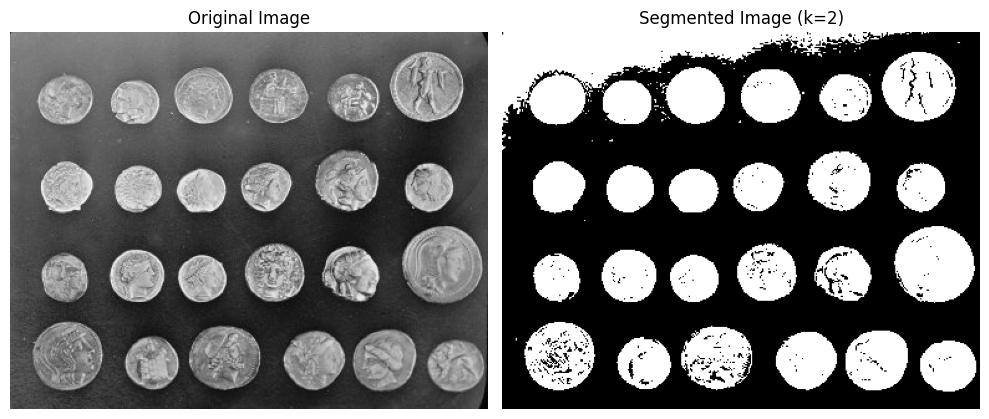

In [ ]:
import matplotlib.pyplot as plt
from skimage import data
from sklearn.cluster import KMeans

coins = data.coins()

# Reshaping image into a 2D array (one pixel per row)
pixels = coins.reshape(-1, 1)

# Applying K-Means clustering with k = 2
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(pixels)

# Reshaping labels back to image dimensions
segmented = kmeans.labels_.reshape(coins.shape)

# Displaying original and segmented images
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Original image
axes[0].imshow(coins, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

# Segmented image
axes[1].imshow(segmented, cmap='gray')
axes[1].set_title('Segmented Image (k=2)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

The image was segmented using the K-Means clustering algorithm with k=2.
Each pixel was grouped into one of two clusters according to its grayscale intensity values.
The resulting segmented image separates the coins from the darker background regions.

## 5. Label the objects found in the image. Generate a figure with the original image and the labeled image. How many coins are there in the image?

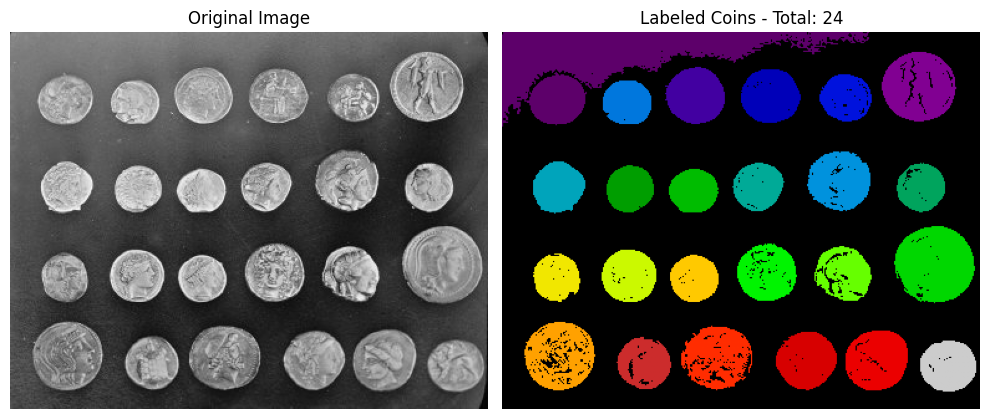

Number of coins in the image: 24


In [ ]:
import matplotlib.pyplot as plt
from skimage import data
from skimage.filters import threshold_otsu
from skimage.measure import label
from skimage.morphology import remove_small_objects

coins = data.coins()

# Applying Otsu threshold
threshold = threshold_otsu(coins)
binary_coins = coins > threshold

# Removing small noisy objects
binary_coins_cleaned = remove_small_objects(binary_coins, min_size=100)

# Labeling connected objects
labeled_coins, num_coins = label(binary_coins_cleaned, return_num=True)

# Displaying results
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Original image
axes[0].imshow(coins, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

# Labeled image
axes[1].imshow(labeled_coins, cmap='nipy_spectral')
axes[1].set_title(f'Labeled Coins - Total: {num_coins}')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Printing number of coins
print(f'Number of coins in the image: {num_coins}')

## 6. Extract the area, major axis length and orientation of each coin. Report the average values of the extracted features. Represent a scatterplot of the area vs major axis length.  

      area  major_axis_length  orientation
0   8755.0         291.294551    -1.423307
1   2459.0          59.966495     1.552547
2   1684.0          47.400067     1.330651
3   1631.0          47.608317     1.560757
4   1193.0          41.310433     1.383445
5   1133.0          39.977857     1.446910
6   1834.0          51.413541     1.532118
7   1325.0          42.451724    -0.883311
8   1203.0          40.921169    -1.034534
9   1133.0          39.719469    -0.873364
10  1129.0          39.179294    -0.923138
11  1104.0          39.634983    -1.500398
12  3054.0          64.238604     1.321690
13  1633.0          48.455200    -1.482099
14  1352.0          47.315544     0.943862
15  1461.0          44.279748     1.510757
16  1095.0          37.726049    -1.098781
17  1148.0          39.093268     1.512176
18  2099.0          58.230243    -1.108783
19  1954.0          55.822104    -1.406812
20  1918.0          52.847912    -0.985728
21  1728.0          48.536525    -1.134875
22  1312.0 

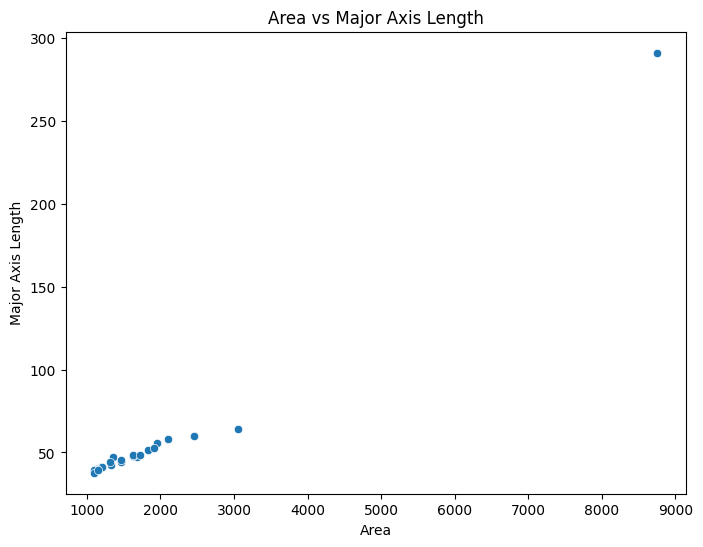

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from skimage.measure import regionprops_table

# Extracting properties from labeled coins
props = regionprops_table(
    labeled_coins,
    properties=['area', 'major_axis_length', 'orientation']
)

# Converting to DataFrame
df_features = pd.DataFrame(props)

# Displaying extracted features
print(df_features)

# Average values
print('Average area:', df_features['area'].mean())
print('Average major axis length:', df_features['major_axis_length'].mean())
print('Average orientation:', df_features['orientation'].mean())

# Scatterplot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='area',
    y='major_axis_length',
    data=df_features
)

plt.title('Area vs Major Axis Length')
plt.xlabel('Area')
plt.ylabel('Major Axis Length')
plt.show()

## 7. Using the labeled regions from the 'coins' image, how can I filter the regions to find those with an area greater than 1750 pixels, count how many such coins there are?

In [ ]:
# Filtering regions with area > 1750
filtered_coins = df_features[df_features['area'] > 1750]

# Counting how many coins satisfy the condition
num_filtered_coins = filtered_coins.shape[0]

print(f'Number of coins with area > 1750 pixels: {num_filtered_coins}')

Number of coins with area > 1750 pixels: 7


The extracted region properties were filtered based on the area feature.
Only coins with an area greater than 1750 pixels were selected.
The number of coins satisfying this condition was then counted.
This filtering helps distinguish larger coins from smaller ones in the image.

##8. Generate a 3-panel figure with the original image, the image with the little coins < 1750 coins (red color) and an image with the big coins > 1750 (blue color).

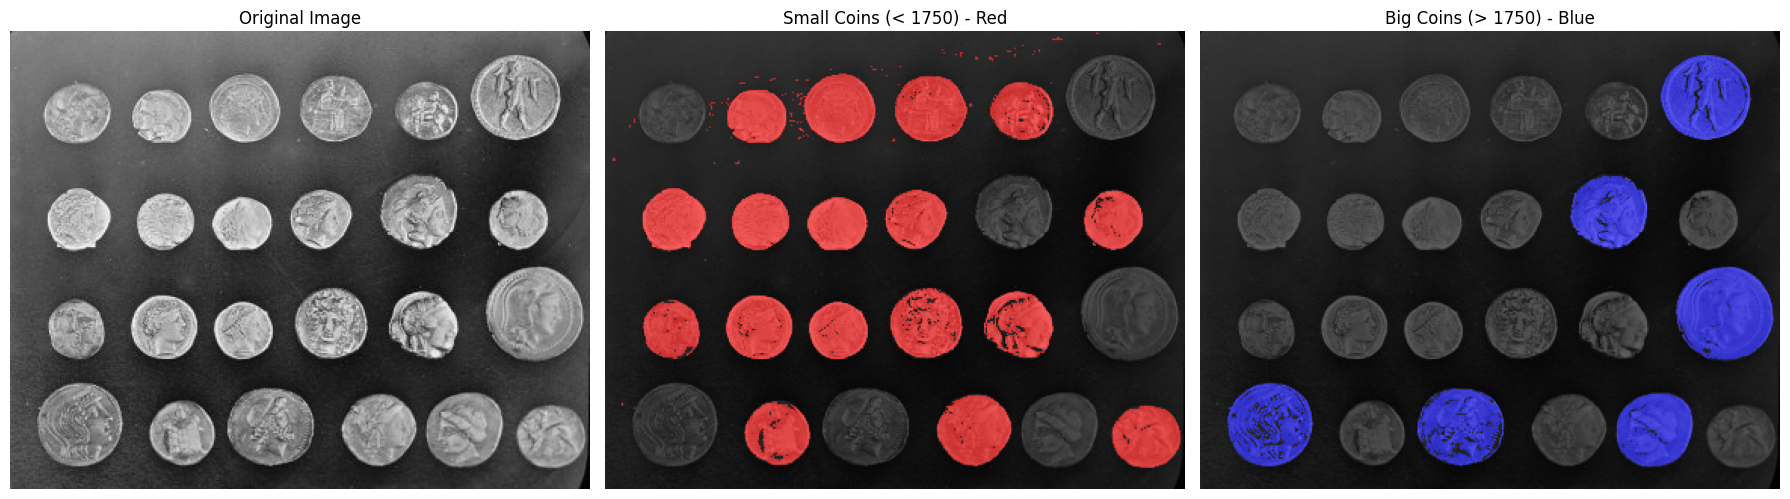

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops
from skimage.segmentation import clear_border

coins = data.coins()

# Creating binary image using Otsu
threshold = threshold_otsu(coins)
binary = coins > threshold

# Removing border objects
cleared = clear_border(binary)

# Label connected components
label_image = label(cleared)

# Getting region properties
regions = regionprops(label_image)

# Creating RGB masks
small_coins_img = np.zeros((*coins.shape, 3), dtype=np.uint8)
big_coins_img = np.zeros((*coins.shape, 3), dtype=np.uint8)

area_threshold = 1750

for region in regions:
    mask = label_image == region.label

    if region.area < area_threshold:
        small_coins_img[mask] = [255, 0, 0]  # red
    else:
        big_coins_img[mask] = [0, 0, 255]    # blue

# Converting original image to RGB
coins_rgb = color.gray2rgb(coins)

# Plot results
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(coins, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(coins_rgb)
axes[1].imshow(small_coins_img, alpha=0.6)
axes[1].set_title('Small Coins (< 1750) - Red')
axes[1].axis('off')

axes[2].imshow(coins_rgb)
axes[2].imshow(big_coins_img, alpha=0.6)
axes[2].set_title('Big Coins (> 1750) - Blue')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 9. Describe the main steps required to perform  segmentation of an RGB image using an unsupervised clustering algorithm (use other algorithms different than K-Means and compare the results)

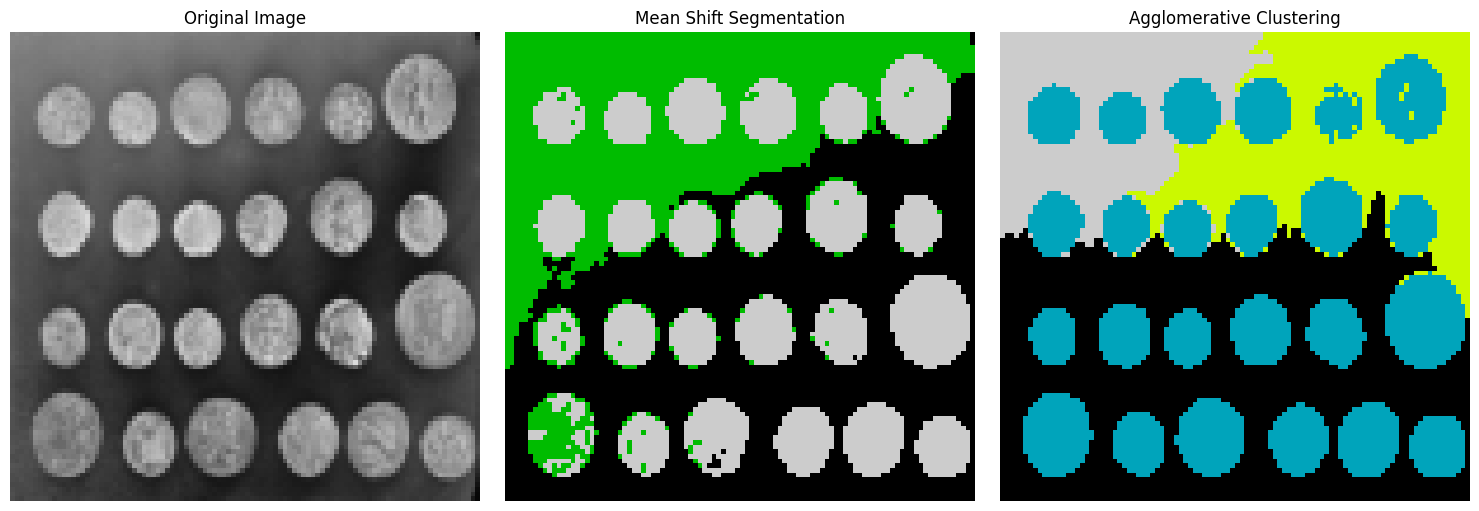

In [ ]:
from skimage import data
from skimage.color import gray2rgb
from skimage.transform import resize
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MeanShift, AgglomerativeClustering
import numpy as np
import matplotlib.pyplot as plt

# Loading image and convert to RGB
image = gray2rgb(data.coins())

# Resizing for faster computation
image_small = resize(image, (100, 100), anti_aliasing=True)
h, w, c = image_small.shape

# Featuring extraction (RGB + spatial info)
pixels = image_small.reshape(-1, 3)

x_coords, y_coords = np.meshgrid(np.arange(w), np.arange(h))
spatial = np.stack([x_coords.ravel(), y_coords.ravel()], axis=1)

features = np.hstack((pixels, spatial))

# Standardize features
features_std = StandardScaler().fit_transform(features)

# Mean Shift clustering
meanshift = MeanShift(bandwidth=1.5, bin_seeding=True)
labels_meanshift = meanshift.fit_predict(features_std)

# Agglomerative clustering
agglo = AgglomerativeClustering(n_clusters=4)
labels_agglo = agglo.fit_predict(features_std)

# Reshaping to image
seg_meanshift = labels_meanshift.reshape(h, w)
seg_agglo = labels_agglo.reshape(h, w)

# Plot results
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(image_small)
axs[0].set_title("Original Image")
axs[0].axis('off')

axs[1].imshow(seg_meanshift, cmap='nipy_spectral')
axs[1].set_title("Mean Shift Segmentation")
axs[1].axis('off')

axs[2].imshow(seg_agglo, cmap='nipy_spectral')
axs[2].set_title("Agglomerative Clustering")
axs[2].axis('off')

plt.tight_layout()
plt.show()

To segment an RGB image using unsupervised clustering methods (other than K-Means), the image is first reshaped so that each pixel is represented as a feature vector defined by its RGB values. Additional spatial coordinates can also be included to preserve spatial consistency.

In this implementation, two clustering algorithms are used: Mean Shift and Agglomerative Clustering.

Mean Shift does not require specifying the number of clusters and identifies clusters by locating high-density regions in the feature space. It tends to produce smooth and adaptive segmentation results.

Agglomerative Clustering is a hierarchical method that iteratively merges similar pixels into clusters based on distance criteria. It requires a predefined number of clusters and usually produces more structured and sharper segment boundaries.

After clustering, each pixel is assigned a label, which is reshaped back into image form to produce the segmented images.

In comparison, Mean Shift produces more natural and continuous regions, while Agglomerative Clustering produces more rigid and well-separated segments. The choice of method affects the smoothness and granularity of the segmentation.

## 10. Extract the main texture features of this image

In [ ]:

!pip install -U scikit-image --quiet

import numpy as np
from skimage import data
from skimage.feature import graycomatrix, graycoprops

coins = data.coins()

# Quantizing image (reduce gray levels)
coins_quantized = (coins / 16).astype(np.uint8)

# Computing GLCM
glcm = graycomatrix(
    coins_quantized,
    distances=[1],
    angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
    levels=16,
    symmetric=True,
    normed=True
)

# Extracting texture features
contrast = graycoprops(glcm, 'contrast')
dissimilarity = graycoprops(glcm, 'dissimilarity')
homogeneity = graycoprops(glcm, 'homogeneity')
energy = graycoprops(glcm, 'energy')
correlation = graycoprops(glcm, 'correlation')
asm = graycoprops(glcm, 'ASM')

# Print results
print("Contrast:\n", contrast)
print("Dissimilarity:\n", dissimilarity)
print("Homogeneity:\n", homogeneity)
print("Energy:\n", energy)
print("Correlation:\n", correlation)
print("ASM:\n", asm)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 66.8 MB/s eta 0:00:00
Contrast:
 [[1.50463166 2.21389172 1.43890556 2.19593485]]
Dissimilarity:
 [[0.57972925 0.72692062 0.5847044  0.72281396]]
Homogeneity:
 [[0.77986311 0.74143872 0.77403261 0.74249939]]
Energy:
 [[0.22393403 0.21027677 0.21912031 0.21034018]]
Correlation:
 [[0.93180265 0.89979668 0.93479003 0.90060894]]
ASM:
 [[0.05014645 0.04421632 0.04801371 0.04424299]]


The main texture features of the image were extracted using the Gray-Level Co-occurrence Matrix (GLCM).
The image was first quantized to reduce the number of gray levels and make computation more efficient.

The GLCM was computed at different directions (0°, 45°, 90°, and 135°) and used to extract several texture descriptors like Contrast, Dissimilarity, Homogeneity, Energy, Correlation.

These features describe the structural texture of the coins image and help distinguish smooth regions (coins surface) from more irregular background areas.

## Personal discussion

Provide a thoughtful reflection on the Computer Vision course, including your perspective on the knowledge you have acquired and your opinion about the professor. (Thank you very much for your feedback!)

During this Computer Vision course, I learned key concepts such as image processing, filtering, segmentation, clustering, and texture analysis. The practical exercises helped me understand how these techniques are applied in real-world problems and improved my Python skills in image analysis.

I found the course well-structured and focused on practical applications, which made the material easier to understand and more engaging.

Regarding the professor, I appreciated the clear explanations and the emphasis on practical use cases rather than only theory. This approach made the course more interesting and useful for understanding real applications of computer vision.